In [10]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['STZhongsong']
plt.rcParams['axes.unicode_minus'] = False

import time
import threading
from filecmp import cmp
import os

timeA = []
timeB = []
timeC = []
checkpoint_error = []
timeoutpointA_error = []
timeoutpointB_error = []
timeoutpointC_error = []

def print_red(content:str):
    print("\033[0;31;40m%s\033[0m" % content)
def print_cyan(content:str):
    print("\033[0;36;40m%s\033[0m" % content)

def testA(order:int, timelimit:float):
    start = time.time()
    os.system("A\\KMP.exe <input\\%d.in >A\\output\\%d.out" % (order, order))
    cost = time.time() - start
    timeA.append(cost)
    if cost < timelimit:
        print("程序A成功输出！用时%fs！" % cost)

def testB(order:int, timelimit:float):
    start = time.time()
    os.system("B\\TRIE.exe <input\\%d.in >B\\output\\%d.out" % (order, order))
    cost = time.time() - start
    timeB.append(cost)
    if cost < timelimit:
        print("程序B成功输出！用时%fs！" % cost)

def testC(order:int, timelimit:float):
    start = time.time()
    os.system("C\\Aho-Corasick.exe <input\\%d.in >C\\output\\%d.out" % (order, order))
    cost = time.time() - start
    timeC.append(cost)
    if cost < timelimit:
        print("程序C成功输出！用时%fs！" % cost)

def check(order:int, timelimit:float):
    global checkpoint_error
    print("数据点：%d" % order)

    threadA = threading.Thread(target = testA, args = (order, timelimit,))
    start = time.time()
    threadA.start()
    threadA.join(timelimit * 2)
    cost = time.time() - start
    if cost > timelimit * 2:
        print_red("A程序严重超时！")
        timeoutpointA_error.append(order)
    elif cost > timelimit:
        print_cyan("A程序超时！用时%fs！" % cost)
        timeoutpointA_error.append(order)

    threadB = threading.Thread(target = testB, args = (order, timelimit,))
    start = time.time()
    threadB.start()
    threadB.join(timelimit * 2)
    cost = time.time() - start
    if cost > timelimit * 2:
        print_red("B程序严重超时！")
        timeoutpointB_error.append(order)
    elif cost > timelimit:
        print_cyan("B程序超时！用时%fs！" % cost)
        timeoutpointB_error.append(order)

    threadC = threading.Thread(target = testC, args = (order, timelimit,))
    start = time.time()
    threadC.start()
    threadC.join(timelimit * 2)
    cost = time.time() - start
    if cost > timelimit * 2:
        print_red("C程序严重超时！")
        timeoutpointC_error.append(order)
    elif cost > timelimit:
        print_cyan("C程序超时！用时%fs！" % cost)
        timeoutpointC_error.append(order)

    if (cmp("C\\output\\%d.out" % order, "A\\output\\%d.out" % order)
        and cmp("C\\output\\%d.out" % order, "B\\output\\%d.out" % order)):
        print("通过！")
    else:
        checkpoint_error.append(order)
        print_red("输出不一致！")
    print()

for i in range(1, 101):
    check(i, 1)

数据点：1
程序A成功输出！用时0.045998s！
程序B成功输出！用时0.025000s！
程序C成功输出！用时0.025004s！
通过！

数据点：2
程序A成功输出！用时0.046263s！
程序B成功输出！用时0.027005s！
程序C成功输出！用时0.025546s！
通过！

数据点：3
程序A成功输出！用时0.046000s！
程序B成功输出！用时0.024002s！
程序C成功输出！用时0.024998s！
通过！

数据点：4
程序A成功输出！用时0.046001s！
程序B成功输出！用时0.024407s！
程序C成功输出！用时0.024999s！
通过！

数据点：5
程序A成功输出！用时0.046356s！
程序B成功输出！用时0.026000s！
程序C成功输出！用时0.026000s！
通过！

数据点：6
程序A成功输出！用时0.045000s！
程序B成功输出！用时0.023998s！
程序C成功输出！用时0.025002s！
通过！

数据点：7
程序A成功输出！用时0.045601s！
程序B成功输出！用时0.024758s！
程序C成功输出！用时0.025001s！
通过！

数据点：8
程序A成功输出！用时0.047563s！
程序B成功输出！用时0.024999s！
程序C成功输出！用时0.024000s！
通过！

数据点：9
程序A成功输出！用时0.045000s！
程序B成功输出！用时0.025000s！
程序C成功输出！用时0.023515s！
通过！

数据点：10
程序A成功输出！用时0.050000s！
程序B成功输出！用时0.024002s！
程序C成功输出！用时0.025823s！
通过！

数据点：11
程序A成功输出！用时0.045999s！
程序B成功输出！用时0.024002s！
程序C成功输出！用时0.024012s！
通过！

数据点：12
程序A成功输出！用时0.046001s！
程序B成功输出！用时0.023999s！
程序C成功输出！用时0.024018s！
通过！

数据点：13
程序A成功输出！用时0.045595s！
程序B成功输出！用时0.024000s！
程序C成功输出！用时0.023998s！
通过！

数据点：14
程序A成功输出！用时0.046006s！
程序B成功输

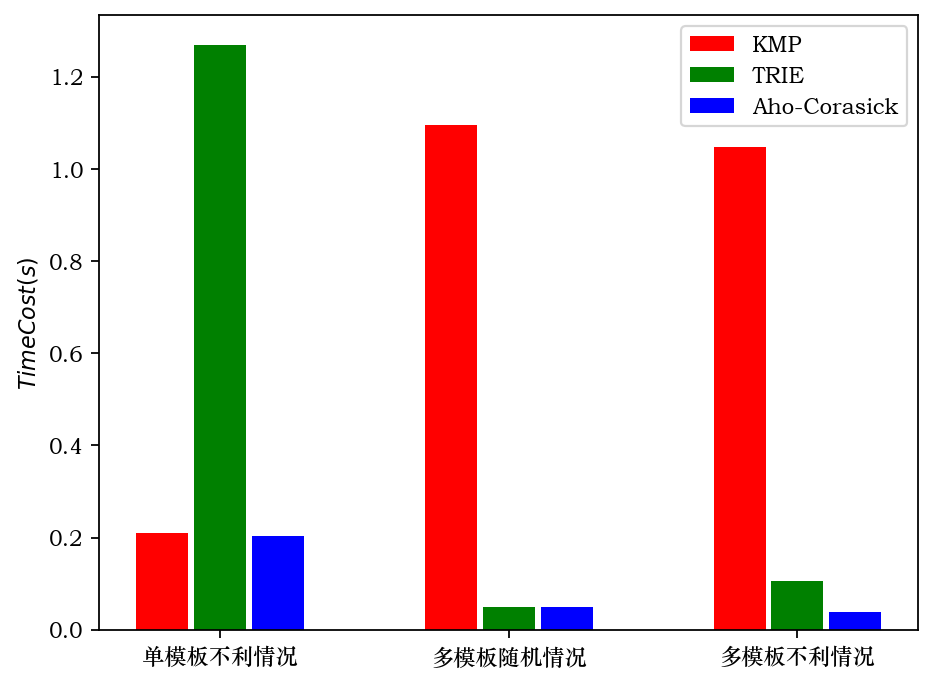

In [13]:
fig = plt.figure(dpi = 160.0)
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

time_1 = [np.average(timeA[70: 80]), np.average(timeA[80: 90]), np.average(timeA[90: 100])]
time_2 = [np.average(timeB[70: 80]), np.average(timeB[80: 90]), np.average(timeB[90: 100])]
time_3 = [np.average(timeC[70: 80]), np.average(timeC[80: 90]), np.average(timeC[90: 100])]

x = [1, 2, 3]
plt.bar(x, time_1, width = 0.18, color = 'red', label = 'KMP')
plt.bar([i + 0.2 for i in x], time_2, width = 0.18, color = 'green', label = 'TRIE')
plt.bar([i + 0.4 for i in x], time_3, width = 0.18, color = 'blue', label = 'Aho-Corasick')

plt.ylabel("$TimeCost(s)$")

plt.xticks([i + 0.2 for i in x], ['单模板不利情况', '多模板随机情况', '多模板不利情况'])
plt.legend()
plt.title('')

plt.show()

In [15]:
if len(checkpoint_error) == 0:
    print("程序输出均一致！")
else:
    print("结果错误数据点：")
    print(checkpoint_error)

if len(timeoutpointA_error) != 0:
    print("A超时数据点：")
    print(timeoutpointA_error)

if len(timeoutpointB_error) != 0:
    print("B超时数据点：")
    print(timeoutpointB_error)

if len(timeoutpointC_error) != 0:
    print("C超时数据点：")
    print(timeoutpointB_error)

程序输出均一致！
A超时数据点：
[81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
B超时数据点：
[71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
